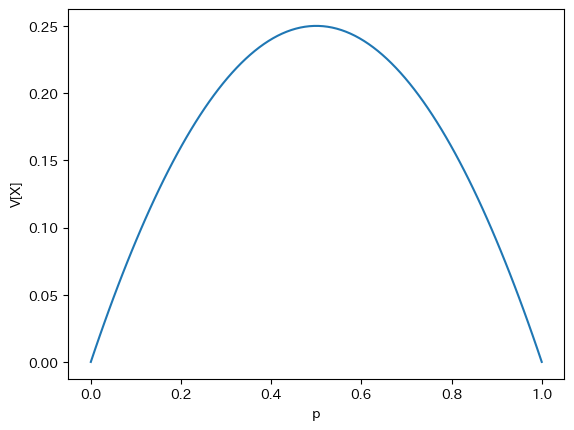

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

X = np.linspace(0, 1, 100)
Y = X - X * X
plt.plot(X, Y)
plt.xlabel("p")
plt.ylabel("V[X]")
plt.show()

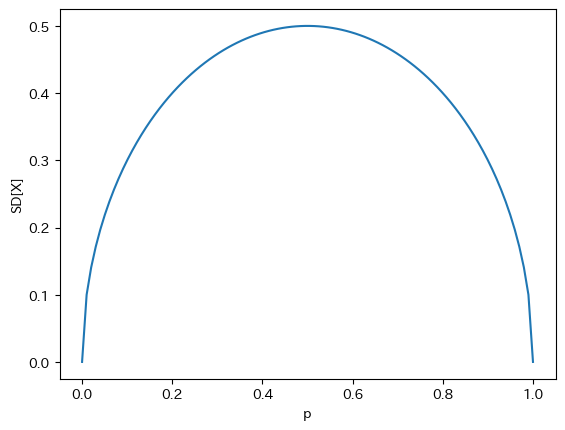

In [2]:
Y = np.sqrt(X - X * X)
plt.plot(X, Y)
plt.xlabel("p")
plt.ylabel("SD[X]")
plt.show()

In [3]:
class MAB:
    def __init__(self, p):
        self.num = len(p)
        self.p = p

    def play(self, arm):
        return int(np.random.rand() < self.p[arm])  

In [4]:
p = [0.2, 0.5, 0.8]
mab = MAB(p = p)

for arm in range(3):
    print(f"コインの獲得確率が {p[arm]} のスロットマシン")
    for i in range(10):
        print(mab.play(arm))

コインの獲得確率が 0.2 のスロットマシン
1
0
1
0
0
0
1
0
0
0
コインの獲得確率が 0.5 のスロットマシン
1
1
0
1
0
0
1
0
0
1
コインの獲得確率が 0.8 のスロットマシン
1
1
1
1
1
0
1
1
1
1


In [5]:
from marubatsu import Marubatsu
from collections import defaultdict

mb = Marubatsu()
legal_moves = mb.calc_legal_moves()
wincount = defaultdict(int)
pnum = 10000

for move in legal_moves:
    mb.move(move)
    for _ in range(pnum):
        result = mb.playout()
        if result == mb.CIRCLE:
            wincount[move] += 1
        elif result == mb.DRAW:
            wincount[move] += 0.5
    mb.unmove()
    
for move in legal_moves:
    print(f"{mb.board.move_to_xy(move)} win ratio = {wincount[move]/pnum:.3f}")

(0, 0) win ratio = 0.674
(0, 1) win ratio = 0.593
(0, 2) win ratio = 0.670
(1, 0) win ratio = 0.601
(1, 1) win ratio = 0.753
(1, 2) win ratio = 0.599
(2, 0) win ratio = 0.667
(2, 1) win ratio = 0.603
(2, 2) win ratio = 0.672


In [6]:
%%timeit

pnum = 100
for move in legal_moves:
    mb.move(move)
    for _ in range(pnum):
        result = mb.playout()
        if result == mb.CIRCLE:
            wincount[move] += 1
        elif result == mb.DRAW:
            wincount[move] += 0.5
    mb.unmove()

11.5 ms ± 512 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [7]:
mab = MAB(p=[0.671, 0.600, 0.671, 0.600, 0.750, 0.600, 0.671, 0.600, 0.671])

wincount = defaultdict(int)
pnum = 10000
for arm in range(9):
    for _ in range(pnum):
        wincount[arm] += mab.play(arm)

for arm in range(9):
    print(f"{arm} win ratio = {wincount[arm]/pnum:.3f}")

0 win ratio = 0.682
1 win ratio = 0.600
2 win ratio = 0.662
3 win ratio = 0.603
4 win ratio = 0.752
5 win ratio = 0.598
6 win ratio = 0.668
7 win ratio = 0.598
8 win ratio = 0.668


In [8]:
%%timeit

wincount = defaultdict(int)
pnum = 100
for arm in range(9):
    for _ in range(pnum):
        wincount[arm] += mab.play(arm)

508 μs ± 10 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
